<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_wave_channels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D12_WAVE_CHANNELS — Field Wave Communication Channel

Status

Working prototype target.

Purpose

This notebook demonstrates information transfer between two bounded field cells through a wave channel.

Previous experiments:

D9_OSCILLATION_CLOCK created a local field clock.

D11_ENTRAINMENT synchronized two field clocks.

D11B_LEADER_FOLLOWER_SYNC showed directed leader-follower synchronization.

This experiment tests whether a leader cell can send a binary signal to a follower cell through a weak wave channel.

Core Idea

Synchronization creates shared rhythm.

Wave channels create communication.

D12 answers:

can one field cell transmit state information to another field cell?

Expected Result

The system should show:

- leader cell sending a binary pulse sequence
- bridge channel carrying the signal
- follower cell receiving the signal
- decoded output matching the input sequence

Diffusion Alphabet Mapping

Symbol:

D12_WAVE_CHANNELS

Family:

Communication / Wave Transport / Field Signaling

Meaning:

A bounded field cell transmits information to another cell through a wave-like channel.

Repository Name

notebooks/diffusion_wave_channels.ipynb

Experiment Label

Experiment 11 — Field Wave Communication Channel

Commit Message

Add field wave channel communication prototype

D12_WAVE_CHANNELS — Field Wave Communication Channel

STATE: CHANNEL_LOCKED
input sequence: 10110101
decoded sequence: 10110101
accuracy: 1.0


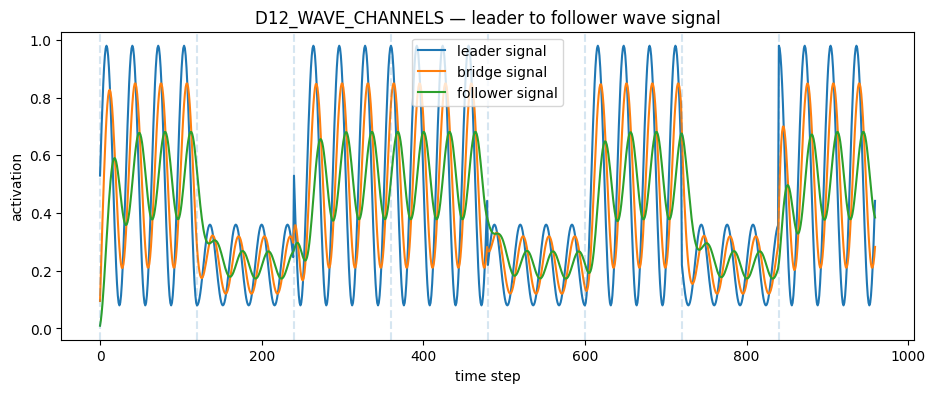

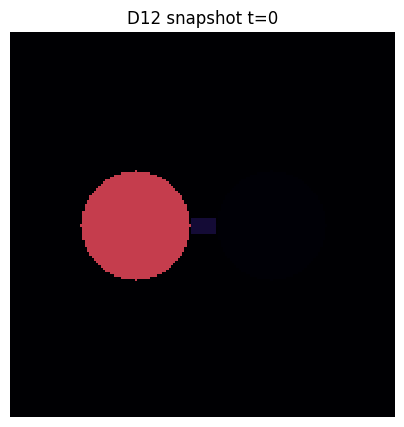

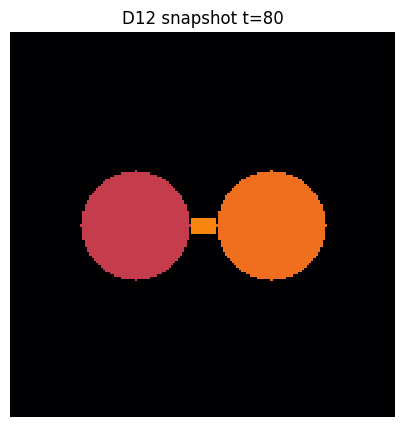

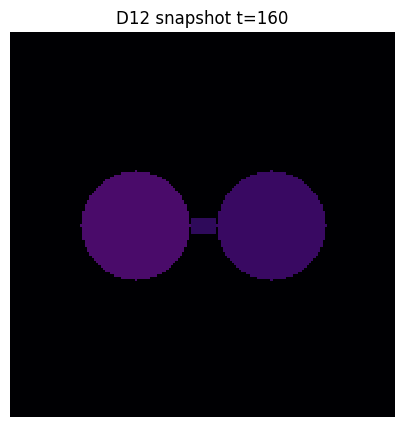

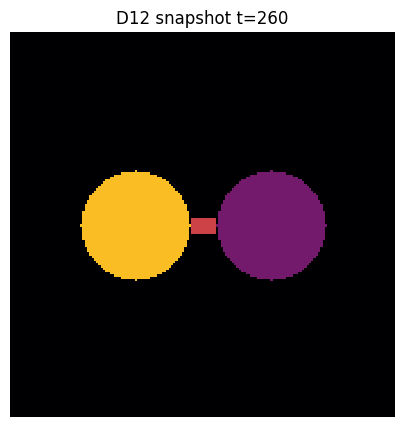

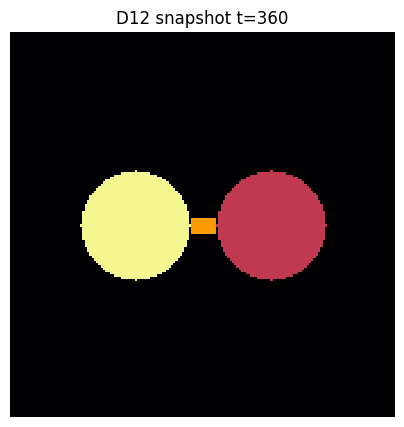

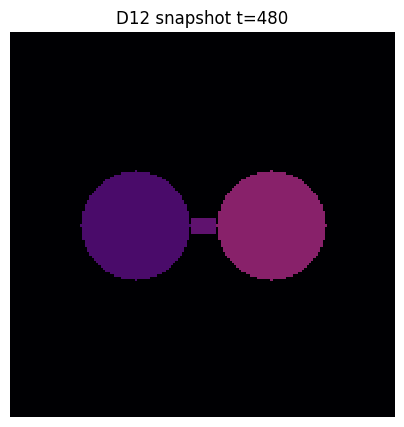

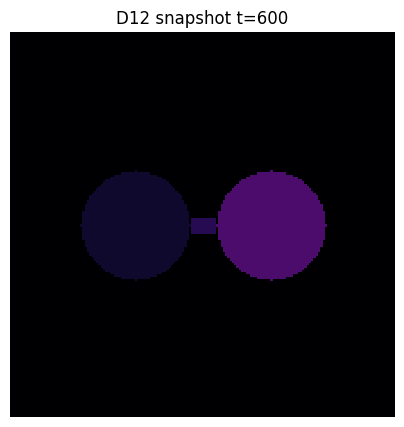

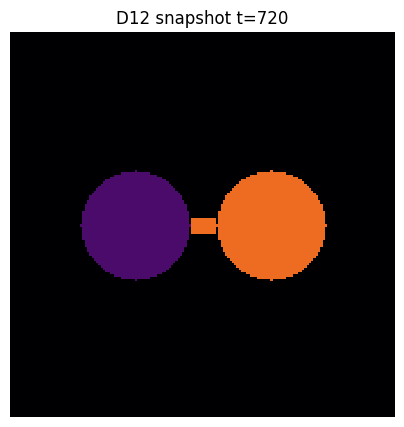

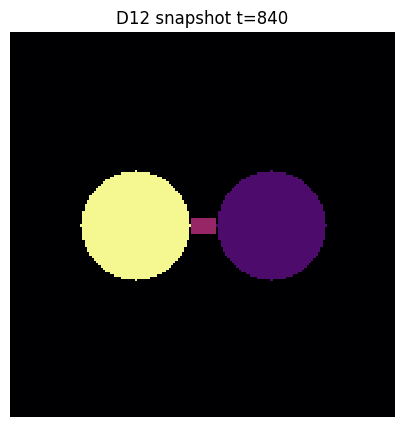

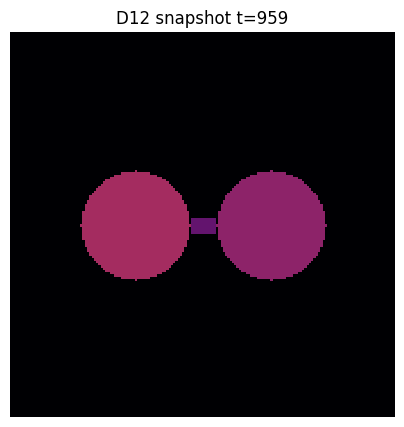

,STATE,BIT_INDEX,INPUT_BIT,RECEIVED_MEAN,DECODED_BIT,MATCH
0,D12_WAVE_CHANNELS,0,1,0.478,1,1
1,D12_WAVE_CHANNELS,1,0,0.266,0,1
2,D12_WAVE_CHANNELS,2,1,0.520,1,1
3,D12_WAVE_CHANNELS,3,1,0.466,1,1
4,D12_WAVE_CHANNELS,4,0,0.282,0,1
5,D12_WAVE_CHANNELS,5,1,0.480,1,1
6,D12_WAVE_CHANNELS,6,0,0.273,0,1
7,D12_WAVE_CHANNELS,7,1,0.538,1,1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def make_wave_channel_masks(size=170, radius=24):
    Y, X = np.ogrid[:size, :size]

    center_leader = (55, size // 2)
    center_follower = (115, size // 2)

    dist_leader = np.sqrt((X - center_leader[0]) ** 2 + (Y - center_leader[1]) ** 2)
    dist_follower = np.sqrt((X - center_follower[0]) ** 2 + (Y - center_follower[1]) ** 2)

    leader_cell = dist_leader <= radius
    follower_cell = dist_follower <= radius

    bridge = (
        (Y >= size // 2 - 3)
        & (Y <= size // 2 + 3)
        & (X > center_leader[0] + radius)
        & (X < center_follower[0] - radius)
    )

    return leader_cell, follower_cell, bridge, center_leader, center_follower


def render_wave_channel_field(
    size,
    leader_cell,
    follower_cell,
    bridge,
    leader_activation,
    bridge_activation,
    follower_activation,
):
    field = np.zeros((size, size), dtype=float)

    field[leader_cell] = leader_activation
    field[bridge] = bridge_activation
    field[follower_cell] = follower_activation

    return field


def run_wave_channel(
    size=170,
    bit_sequence=(1, 0, 1, 1, 0, 1, 0, 1),
    bit_len=120,
    carrier_period=32,
    bridge_gain=0.18,
    follower_gain=0.10,
    low_bit_gain=0.28,
    high_bit_gain=0.90,
    base_signal=0.08,
    decode_delay=35,
    decode_threshold=0.38,
):
    """
    D12_WAVE_CHANNELS

    Leader sends a binary sequence using amplitude modulation.

    bit = 1 -> stronger wave envelope
    bit = 0 -> weaker wave envelope

    The bridge carries the signal.
    The follower receives a delayed, smoothed version of the signal.
    """

    bit_sequence = np.array(bit_sequence, dtype=int)
    steps = len(bit_sequence) * bit_len

    leader_cell, follower_cell, bridge, center_leader, center_follower = make_wave_channel_masks(size=size)

    bridge_state = 0.0
    follower_state = 0.0

    omega = 2 * np.pi / carrier_period

    history = []
    snapshots = {}

    for t in range(steps):
        bit_index = min(t // bit_len, len(bit_sequence) - 1)
        bit = int(bit_sequence[bit_index])

        carrier = 0.5 + 0.5 * np.sin(omega * t)

        if bit == 1:
            bit_gain = high_bit_gain
        else:
            bit_gain = low_bit_gain

        leader_activation = base_signal + bit_gain * carrier

        # channel dynamics
        bridge_state += bridge_gain * (leader_activation - bridge_state)
        follower_state += follower_gain * (bridge_state - follower_state)

        leader_activation = float(np.clip(leader_activation, 0, 1))
        bridge_activation = float(np.clip(bridge_state, 0, 1))
        follower_activation = float(np.clip(follower_state, 0, 1))

        history.append(
            {
                "t": t,
                "bit_index": bit_index,
                "input_bit": bit,
                "leader_activation": leader_activation,
                "bridge_activation": bridge_activation,
                "follower_activation": follower_activation,
            }
        )

        if t in [0, 80, 160, 260, 360, 480, 600, 720, 840, steps - 1]:
            snapshots[t] = render_wave_channel_field(
                size=size,
                leader_cell=leader_cell,
                follower_cell=follower_cell,
                bridge=bridge,
                leader_activation=leader_activation,
                bridge_activation=bridge_activation,
                follower_activation=follower_activation,
            )

    history = pd.DataFrame(history)

    decoded_rows = []

    for i, expected_bit in enumerate(bit_sequence):
        start = i * bit_len + decode_delay
        end = min((i + 1) * bit_len + decode_delay, steps)

        sample = history.iloc[start:end]
        received_mean = float(sample["follower_activation"].mean())

        decoded_bit = 1 if received_mean >= decode_threshold else 0

        decoded_rows.append(
            {
                "STATE": "D12_WAVE_CHANNELS",
                "BIT_INDEX": i,
                "INPUT_BIT": int(expected_bit),
                "RECEIVED_MEAN": round(received_mean, 3),
                "DECODED_BIT": int(decoded_bit),
                "MATCH": int(decoded_bit == expected_bit),
            }
        )

    df_decode = pd.DataFrame(decoded_rows)

    accuracy = float(df_decode["MATCH"].mean())

    if accuracy == 1.0:
        result = "CHANNEL_LOCKED"
    elif accuracy >= 0.75:
        result = "PARTIAL_CHANNEL"
    else:
        result = "CHANNEL_FAILED"

    summary = pd.DataFrame(
        [
            {
                "STATE": "D12_WAVE_CHANNELS",
                "RESULT": result,
                "INPUT_SEQUENCE": "".join(str(x) for x in bit_sequence),
                "DECODED_SEQUENCE": "".join(str(x) for x in df_decode["DECODED_BIT"].values),
                "ACCURACY": round(accuracy, 3),
                "BIT_LEN": bit_len,
                "DECODE_DELAY": decode_delay,
                "DECODE_THRESHOLD": decode_threshold,
            }
        ]
    )

    return history, snapshots, df_decode, summary


history, snapshots, df_decode, summary = run_wave_channel()

print("STATE:", summary["RESULT"].iloc[0])
print("input sequence:", summary["INPUT_SEQUENCE"].iloc[0])
print("decoded sequence:", summary["DECODED_SEQUENCE"].iloc[0])
print("accuracy:", summary["ACCURACY"].iloc[0])

plt.figure(figsize=(11, 4))
plt.plot(history["t"], history["leader_activation"], label="leader signal")
plt.plot(history["t"], history["bridge_activation"], label="bridge signal")
plt.plot(history["t"], history["follower_activation"], label="follower signal")

for bit_start in range(0, len(history), 120):
    plt.axvline(bit_start, linestyle="--", alpha=0.18)

plt.title("D12_WAVE_CHANNELS — leader to follower wave signal")
plt.xlabel("time step")
plt.ylabel("activation")
plt.legend()
plt.show()

for t, snap in snapshots.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(snap, cmap="inferno", vmin=0, vmax=1, interpolation="nearest")
    plt.title(f"D12 snapshot t={t}")
    plt.axis("off")
    plt.show()

df_decode

In [2]:
summary

,STATE,RESULT,INPUT_SEQUENCE,DECODED_SEQUENCE,ACCURACY,BIT_LEN,DECODE_DELAY,DECODE_THRESHOLD
0,D12_WAVE_CHANNELS,CHANNEL_LOCKED,10110101,10110101,1.0,120,35,0.38
